# Faux

An R package for data simulation from summary statistics

Lisa DeBruine [](https://orcid.org/0000-0002-7523-5539) (University of Glasgow)  
September 25, 2025

Being able to simulate data allows you to prep analysis scripts for pre-registration, calculate power and sensitivity for analyses that don’t have empirical methods, create reproducible examples when your data are too big or confidential to share, enhance your understanding of statistical concepts, and create demo data for teaching and tutorials. In this paper, I will introduce the basics of simulation using the R package {faux} to simulate data from summary statistics. Two conrete examples are presented. First, a fixed 2x2 within-between design demonstrating how to do a power analysis for designs that do not have empirical solutions. Second, simulating data from a mixed design where trials are crossed with subjects in order to understand how the simulation parameters correspond to the output.

In [ ]:
library(faux)


************
Welcome to faux. For support and examples visit:
https://debruine.github.io/faux/
- Get and set global package options with: faux_options()
************

## 1 Introduction

### 1.1 Why simulate data?

#### 1.1.1 Pre-registration

#### 1.1.2 Power and sensitivity

-   You can get empirical power analyses for simple designs, like a paired samples t-test or 1-way ANOVA.
-   This gets trickier is you have unbalanced subject numbers, although {Superpower} can do this (by using a simulation method that was derived from an early version of faux)
-   However, if you can simulate your data, you can analyse it with any method and calculate power, sensitivity, or any other metric you are interested in.
-   The caveat here is that it is not always straightforward to know how to simulate data realistically, often because you only have summary data from existing literature.
-   Example of this in <a href="#sec-fixed-power" class="quarto-xref">Section 2.1.2</a> below.

#### 1.1.3 Reproducible examples

-   Although open data sharing should be something we strive to achieve, it is not always legally or ethically possible
-   Datasets can also be too big to feasibly transfer or analyse
-   You can use simulation to create a dataset that has the same summary parameters at the original, but distinct individual values or is much smaller.

#### 1.1.4 Enhance understanding

-   Using summary parameters to generate data can enhance understanding
-   Plot or analyse the simulated data to see how the summary parameters are reflected in the plots or results
-   Change simulation parameters to see how plots and analyses change
-   Example of this in <a href="#sec-mixed-design" class="quarto-xref">Section 2.2</a> below.

#### 1.1.5 Demo teaching data

### 1.2 Existing methods

-   base R
-   excel
-   simr

### 1.3 Faux

-   what gaps does faux fill?
-   focus on summary stats for simulation
-   flexible wide and long data designs
-   shiny app

## 2 Examples

### 2.1 Fixed design

#### 2.1.1 Simulate data

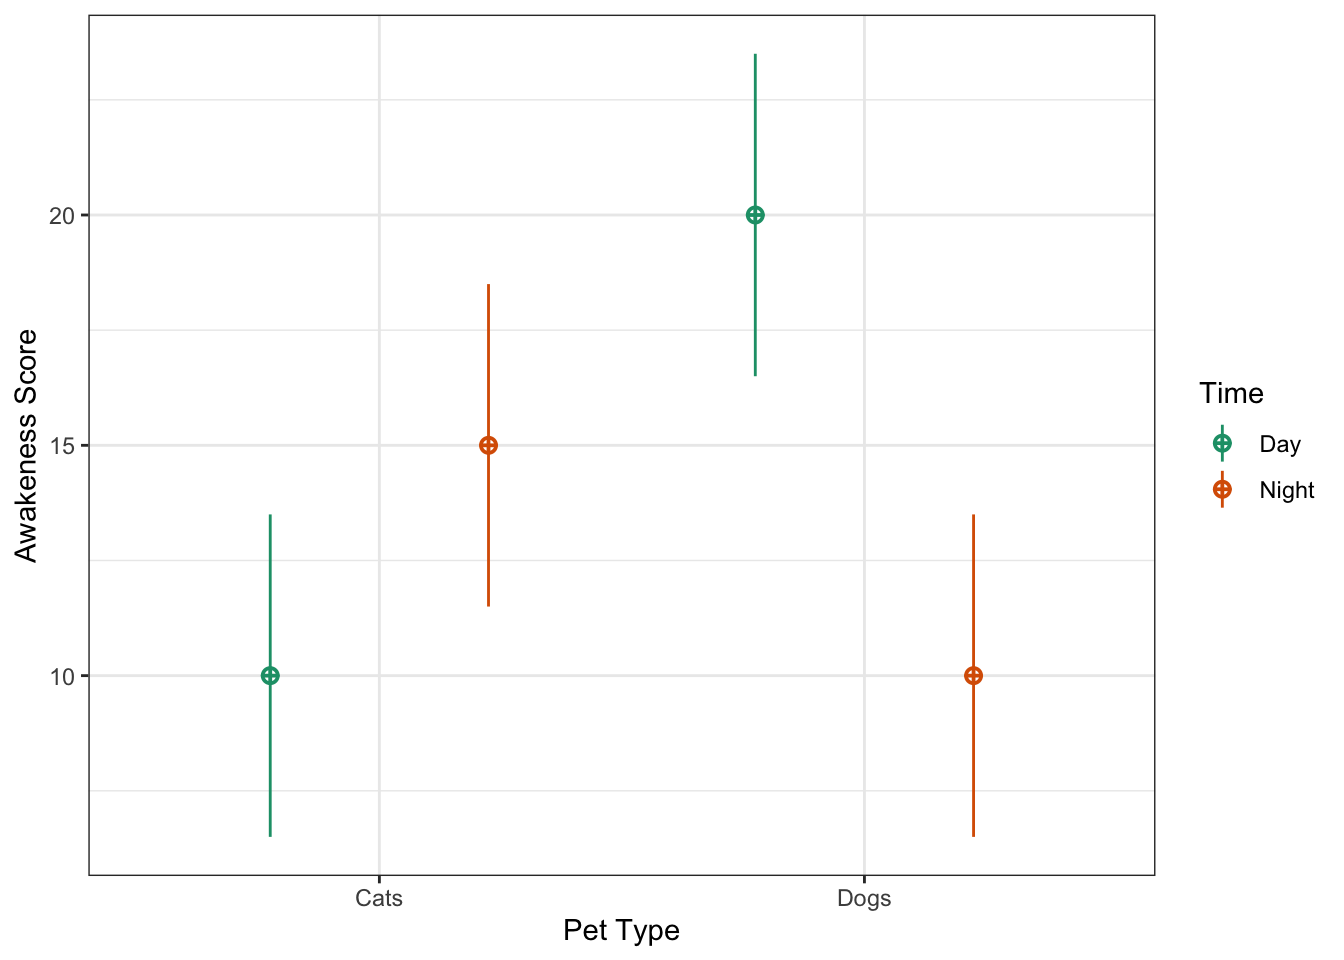

In [ ]:
fixed <- sim_design(
  within = list(time = c(day = "Day", night = "Night")),
  between = list(pet = c(cat = "Cats", dog = "Dogs")),
  mu = c(day_cat = 10, night_cat = 15, day_dog = 20, night_dog = 10),
  sd = 3.5,
  n = c(cat = 20, dog = 25), 
  vardesc = c(pet = "Pet Type", time = "Time"),
  dv = list(score = "Awakeness Score"), 
  long = TRUE
)

Ignoring unknown labels:
• colour : "Time"

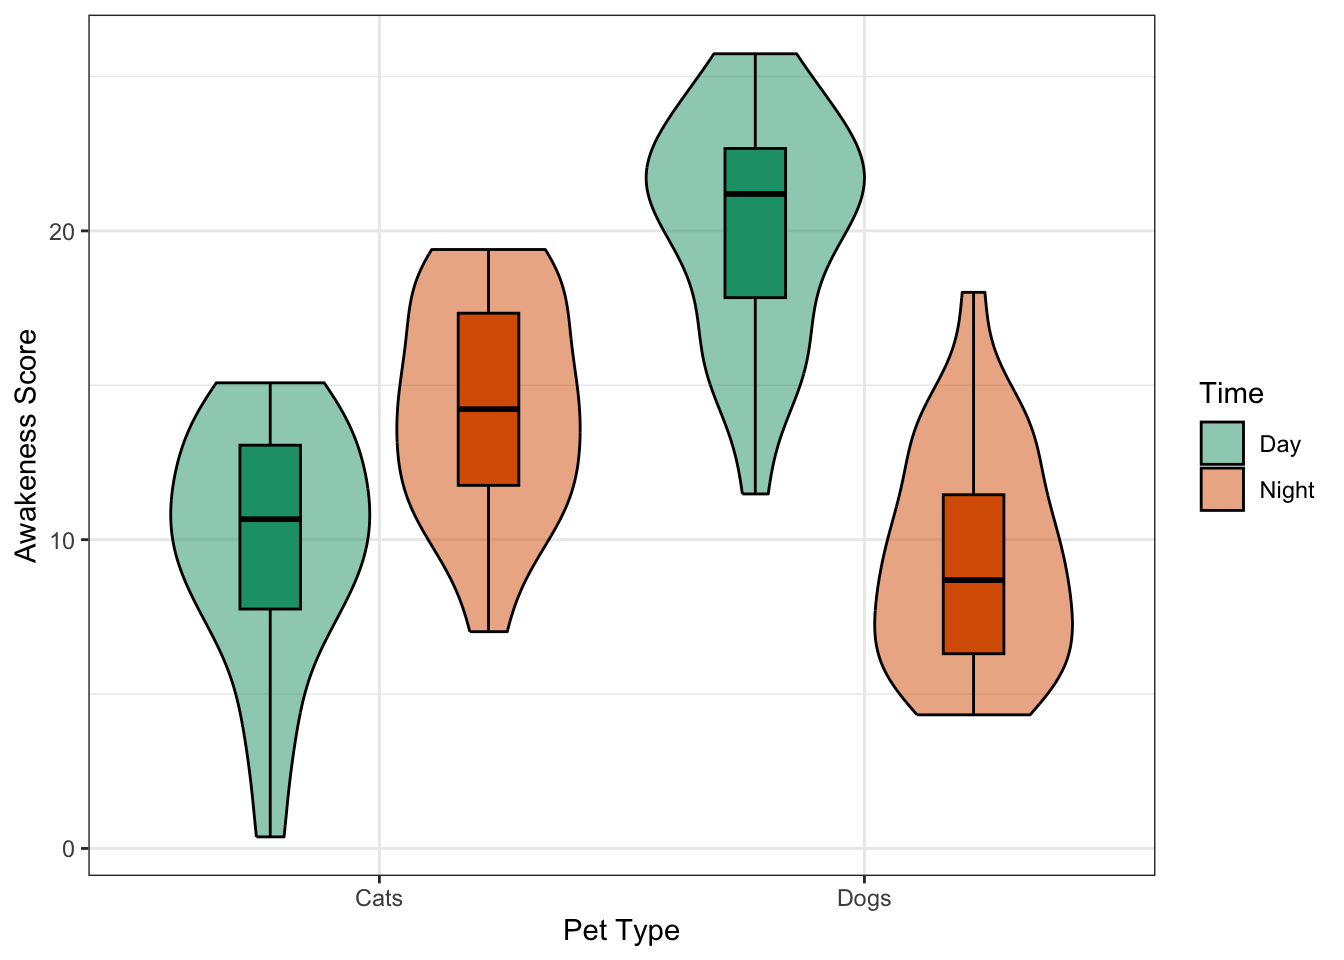

In [ ]:
plot(fixed)

In [ ]:
get_params(fixed)

In [ ]:
get_design(fixed)

* [DV] score: Awakeness Score  
* [ID] id: id  
* Within-subject variables:
    * time: Time: 
        * day: Day
        * night: Night
* Between-subject variables:
    * pet: Pet Type: 
        * cat: Cats
        * dog: Dogs
* Parameters:
    |pet |time  | day| night|  n| mu|  sd|
    |:---|:-----|---:|-----:|--:|--:|---:|
    |cat |day   |   1|     0| 20| 10| 3.5|
    |cat |night |   0|     1| 20| 15| 3.5|
    |dog |day   |   1|     0| 25| 20| 3.5|
    |dog |night |   0|     1| 25| 10| 3.5|

#### 2.1.2 Power analysis

### 2.2 Mixed design

#### 2.2.1 Get parameters

#### 2.2.2 Simulate data

## 3 Discussion

## 4 References